In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [57]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RepeatedKFold, KFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from joblib import dump, load  
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
df = pd.read_csv('../data/insurance.csv')
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


# 1. Calcule estadísticas descriptivas de las variables numéricas:

Análisis esperado: identificar qué variables parecen tener mayor relación con los gastos médicos, detectar posibles valores
atípicos y observar si la distribución de charges es asimétrica

a) Grafica de la distribución de charges.

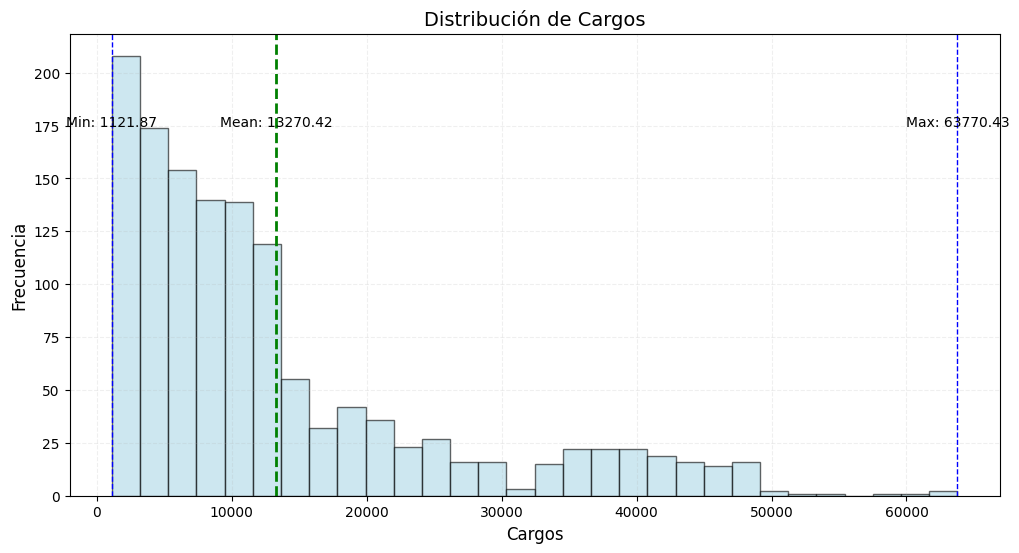

In [4]:
min = df["charges"].min()
max = df["charges"].max()
mean = df["charges"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df["charges"], bins=30, color="lightblue", edgecolor='black', alpha=0.6)

ax.axvline(min, color='blue', linestyle='--', linewidth=1, label=f'Min: {min:.2f}')
ax.axvline(max, color='blue', linestyle='--', linewidth=1, label=f'Max: {max:.2f}')
ax.axvline(mean, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean:.2f}')

ax.text(min, ax.get_ylim()[1]*0.8, f'Min: {min:.2f}', color='black', fontsize=10, ha='center')
ax.text(mean, ax.get_ylim()[1]*0.8, f'Mean: {mean:.2f}', color='black', fontsize=10, ha='center')
ax.text(max, ax.get_ylim()[1]*0.8, f'Max: {max:.2f}', color='black', fontsize=10, ha='center')

ax.set_title("Distribución de Cargos", fontsize=14)
ax.set_xlabel("Cargos", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.grid( linestyle="--", alpha=0.2)


De la gráfica podemos afirmar que la mayor cantidad de gastos por seguro médico se encuentran por debajo de los $20,000 sin embargo la media se encuentra en los $13,270 habiendo personas que llegan a gastar hasta los $63770


b) Analice la relación entre charges y las variables: age, bmi, smoker,


Ahora vamos a graficar la relación de todas las variables numéricas entre sí misma particularmente la última columna nos da la gráfica de la distribución de cargos y su relación con las demás variables; a primera vista podemos observar que no hay una aparente correlación lineal entre las variables índice de masa corporal y número de hijos con la variable que estamos interesados en predecir sin embargo con respecto a la variable edad parece tener una pequeña correlación

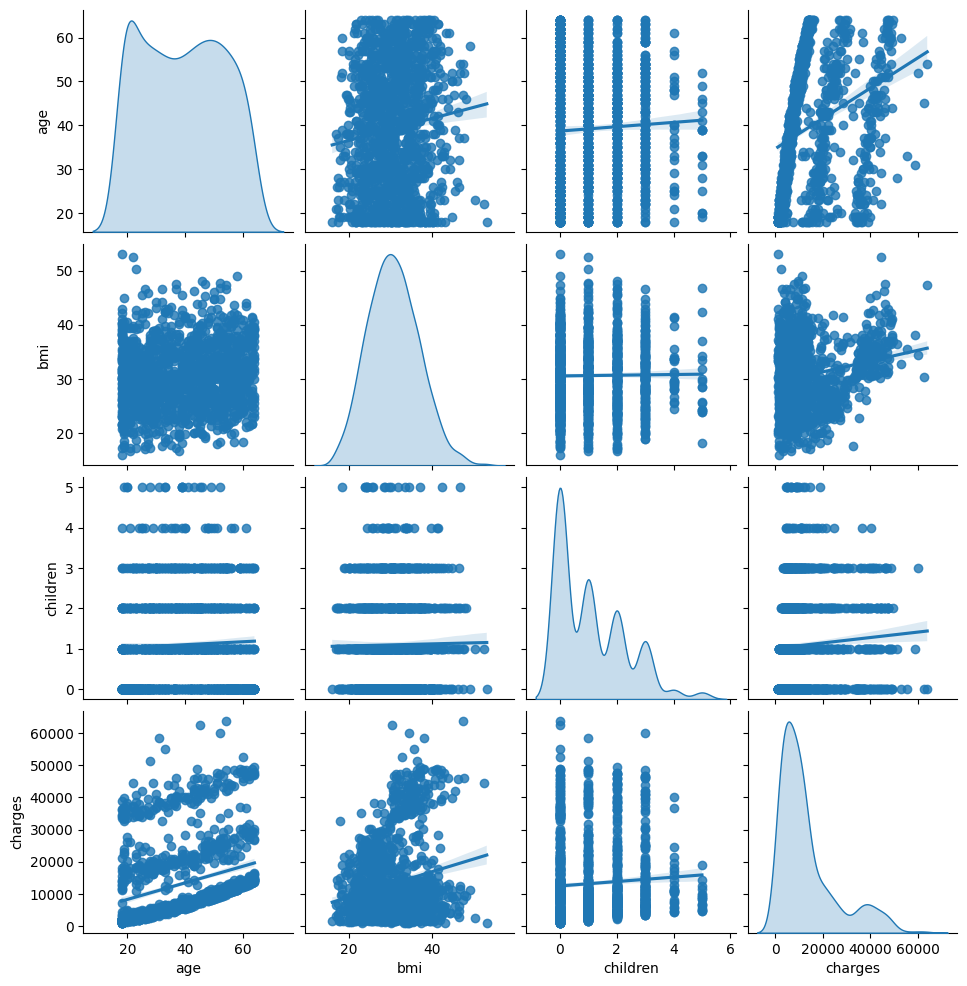

In [5]:
sns.pairplot(df, kind='reg', diag_kind='kde')
# plt.plot(df['age'], df['charges'], 'o')

<!-- Notemos que al graficar la recta de regresión tiene una pendiente ligeramente positiva esto nos indica que efectivamente existe una cierta relación lineal -->

Notemos que al graficar la recta de regresión tiene una pendiente ligeramente positiva esto nos indica que efectivamente existe una cierta relación lineal

En el siguiente gráfico dividimos los datos entre fumadores y no fumadores para ver si existe una diferencia entre la cantidad de gastos conforme su edad aumenta y además si es fumador o no

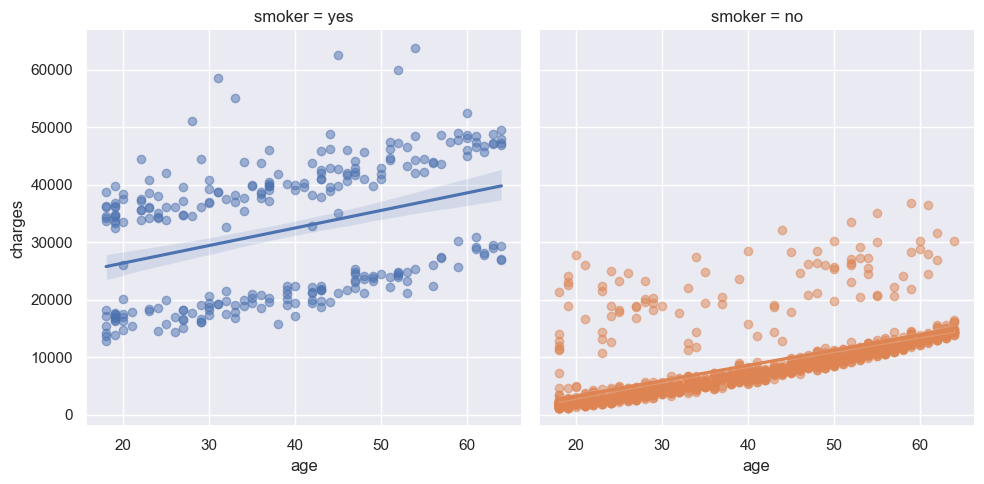

In [6]:
sns.set_theme()
sns.lmplot(x='age', y='charges',col='smoker' ,hue='smoker', data=df, scatter_kws={'alpha':0.5})

Observemos que las personas que fuman por lo regular tienen gastos de salud más altos que las personas que no fuman además conforme aumenta la edad estos cargos suelen aumentar

Ahora al graficar el índice de masa corporal contra los cargos podemos observar que no hay una clara relación que al aumentar el índice de masa corporal también aumente los gastos pues por ejemplo en el lado izquierdo del gráfico azul podemos observar personas con un índice de masa corporal entre 45 y 50 con un cargo de $10,000

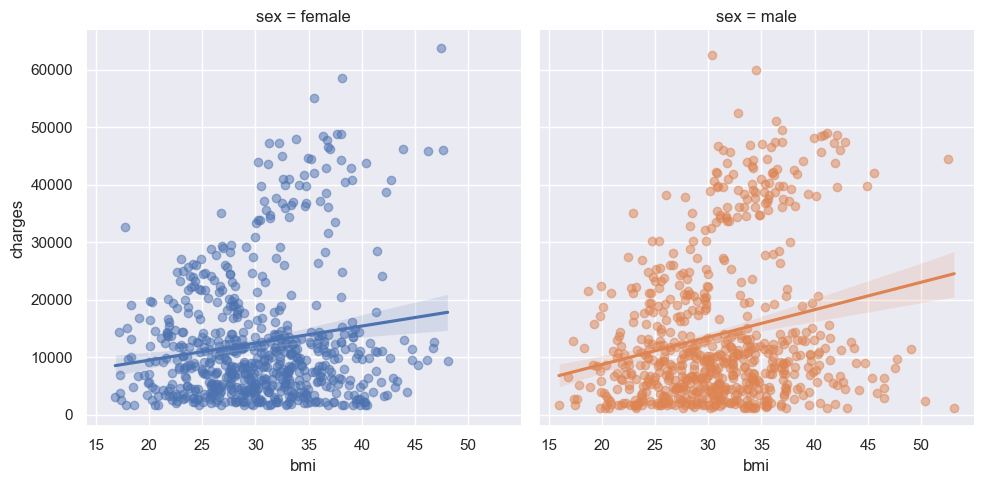

In [7]:
sns.lmplot(x='bmi', y='charges',col='sex' ,hue='sex', data=df, scatter_kws={'alpha':0.5})

 Finalmente graficamos un boxblot entre los cargos y si la persona fumador o no podemos observar que las personas que son fumadores en promedio gastan más encargos médicos que las personas que no son fumadores teniendo algunos pequeños valores atípicos en la variable de los no fumadores

<Axes: xlabel='smoker', ylabel='charges'>

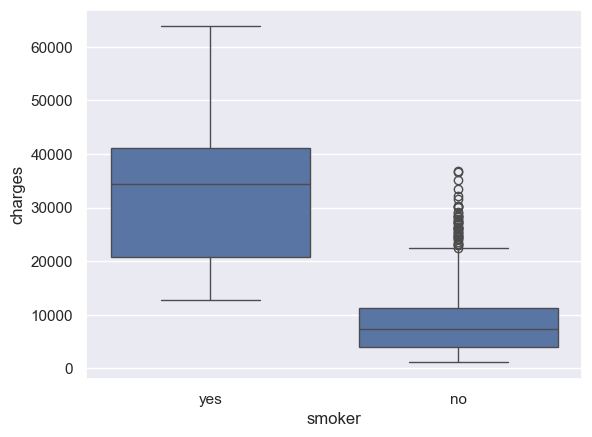

In [8]:
sns.boxplot(x='smoker', y='charges', data=df)

De manera general podemos observar rápidamente que la variable más correlacionada con los cargos es la de la edad ya que conforme esta aumentan los gastos médicos pero también podemos observar que las personas que tienden a fumar suelen tener cargos médicos mayores que las personas que no suelen fumar y esto aumenta conforme aumentan los años.

Por otra parte no encontramos una relación significativa entre el índice de masa corporal y los cargos por los servicios y por último notemos que las personas que suelen fumar suelen tener cargos médicos mayores que las personas que no lo hacen salvo algunos pequeños valores atípicos

<Axes: >

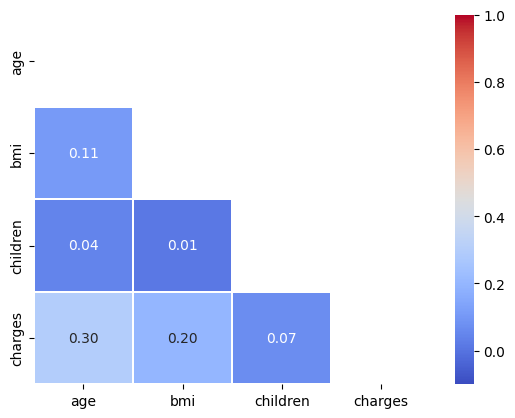

In [75]:
correlaciones =df.corr(numeric_only=True)
mascara = np.triu(np.ones_like(correlaciones, dtype=bool))
sns.heatmap(
    correlaciones, annot = True,
    fmt = ".2f", cmap = "coolwarm",
    vmin = 1, vmax = 0,
    linewidths = 0.3, linecolor = "white", mask = mascara)

Calculando la matriz de correlaaciones podemos observar que la variable edad en efecto es la que guarda mayor relacion con la variable con la que estamos interesados y que cantidad de hijos no tiene tanta correlacion con la variable objetivo

# 2. Antes de aplicar el algoritmo KNN es necesario preparar los datos.

a) Explique por qué es necesario codicar las variables categóricas (sex, smoker, region).

Antes de aplicar nuestra algoritmo knn es necesario codificar las variables categóricas porque nuestro modelo no entiende sobre texto solo entiende números por lo cual es necesario aplicar técnicas como one hot encode o label encoding según según sea el caso de esta forma nuestro modelo puede aprender las relaciones numéricas usando variables categóricas


In [9]:
# df.isnull().sum()
#  no hay datos faltantes

b) Aplique una técnica One-Hot Encoding a las variables categóricas.

c) Estandarice las variables predictoras.

d) Divida el conjunto de datos en entrenamiento (80%) y prueba (20%).

e) por qué el escalamiento es especialmente importante en KNN.


In [10]:

columns_categorical = df.select_dtypes(include=['object', 'str']).columns.tolist()
columns_numerical = df.select_dtypes(include='number').columns.drop('charges').tolist()

preprocesador = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), columns_categorical), # one hot encoding
    ('num', StandardScaler(), columns_numerical) # estandarización
])

X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # división de datos


El escalamientio es especialmente importante en knn puesto que estamos midiendo distancias y el hecho de que tengamos diferentes medidas de distancias para cada una de las variables hace que el modelo sea más inestable al estar considerando diferentes escalas de medicion

# 3. Entrene el algoritmo KNN(k) con distintos valores del número de vecinos: k = 1,3,5,7,9,11,15.
a) Utilice validación cruzada de 10 folds para evaluar el desempeño del modelo.

b) Calcule las siguientes métricas:

        1) MAE (Mean Absolute Error)
        2) RMSE (Root Mean Squared Error)
c) Grafique el error en función de k.

d) cómo cambia el error al aumentar el número de vecinos? qué valor de k parece óptimo?

In [ ]:
espacio_parametral = {
    "kneighborsregressor__n_neighbors": [1,3,5,7,9,11,15]
}

scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error'
}


pipeline = make_pipeline(preprocesador, KNeighborsRegressor())
dis_validation = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42) # validación cruzada repetida de 10 pliegues y 5 repeticiones
grid_search = GridSearchCV(pipeline, 
                           param_grid=espacio_parametral, 
                           cv=dis_validation,
                           scoring=scoring,
                           refit='MAE',
                           n_jobs=-1)   
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...Regressor())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kneighborsregressor__n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'MAE'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedKFold...ndom_state=42)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

In [ ]:

result = pd.DataFrame(grid_search.cv_results_)
rmse_vals = np.sqrt(result['mean_test_MSE'] * -1)
mae_vals = result['mean_test_MAE'] * -1
min_mae = mae_vals.min()
ks = espacio_parametral["kneighborsregressor__n_neighbors"]
mejor_params = grid_search.best_params_
print("Mejores hiperparámetros:", mejor_params)

Mejores hiperparámetros: {'kneighborsregressor__n_neighbors': 2}


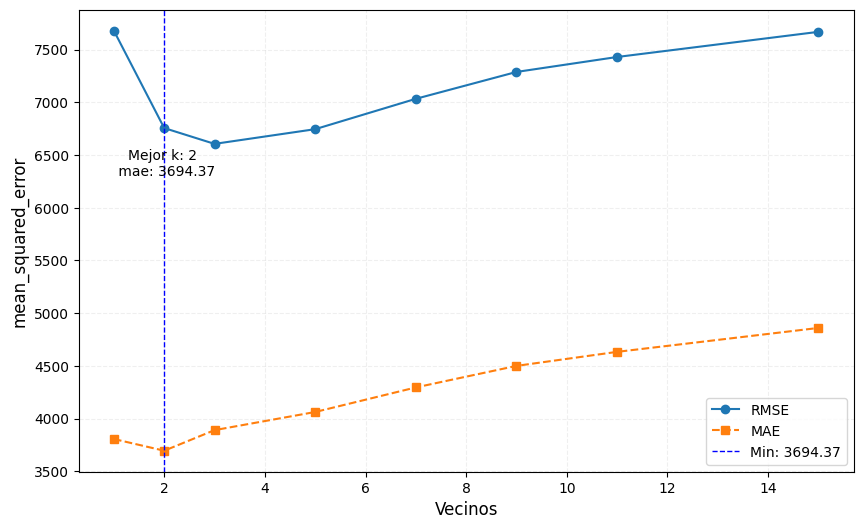

In [ ]:
plt.style.use('default')
plt.figure(figsize=(10, 6))
plt.plot(ks, rmse_vals, marker='o', linestyle='-', label='RMSE')
plt.plot(ks, mae_vals, marker='s', linestyle='--', label='MAE')
plt.axvline(list(mejor_params.values())[0], color='blue', linestyle='--', linewidth=1, label=f'Min: {min_mae:.2f}')
plt.text(list(mejor_params.values())[0], plt.ylim()[1]*0.8, f'Mejor k: {list(mejor_params.values())[0]} \n mae: {min_mae:.2f}', color='black', fontsize=10, ha='center')
plt.xlabel("Vecinos", fontsize=12) 
plt.ylabel("mean_squared_error", fontsize=12)
plt.grid( linestyle="--", alpha=0.2)
plt.legend()
plt.show()


Calculamos ambas métricas y graficamos el error en función de k de esto obtenemos que para el *mean absolute error* el mejor valor de  es k = 3 puesto que es donde se obtiene la menor cantidad de error; en el caso del *mean square error* el mejor valor se obtiene con k = 3.

Notemos que el error aumenta conforme el número de vecinos aumenta siendo los mejores valores los que se mencionaron anteriormente.

# 4. Explique el comportamiento observado en la gráfica anterior en términos del trade-o sesgo-varianza.
a) qué ocurre cuando k = 1

b) qué ocurre cuando k es muy grande

c) cómo influye esto en la capacidad predictiva del modelo

En este caso particular podemos observar que cuando k = 1 el error tiende a ser muy alto, pero a medida que k aumentam, va disminuyendo el error para posteriormente volver a incrementar conforme crece la cantidad de vecinos más cercanos. Sin embargo existe un punto en donde el error es más pequeño y nuestro modelo tiene mejores capacidades para generalizar en este punto.

En términos del trade-off  o el sesgo-varianza le estamos diciendo al modelo que no sea tan complejo para que no tenga un sobre ajuste pero que tampoco sea tan simple para que tenga buena capacidad de generalización, esto nos ayuda a seleccionar el mejor modelo para tener mejores predicciones a la hora de observar datos nuevos.

# 5. Seleccione el valor óptimo de k y entrene el modelo utilizando el conjunto de entrenamiento.
Evalúe el modelo en el conjunto de prueba calculando:

a) MAE.

b) RMSE.

c) R2.

d) Interprete los resultados: qué tan grande es el error promedio de predicción?. ¾el modelo parece adecuado para
predecir gastos médicos? qué variables podrían explicar los errores más grandes?

In [ ]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


In [63]:
print(f"{"--"*10} Evaluación del modelo {"--"*10}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.2f}")

-------------------- Evaluación del modelo --------------------
MAE: 1816.10
MSE: 8984104.68
R2: 0.91


Notemos que el error de predicción no es demasiado grande de hecho 1816.10 es el error promedio de predicción usando el mae lo cual parece un buen modelo para predecir los gastos médicos quizá podríamos refinar más utilizando alguna ingeniería de atributos o en su defecto eliminar variables poco correlacionadas, incluso nuestro modelo llegó a por decir el 91% de la variabilidad

Entre las variables que podrían explicar mejores los errores grandes se encuentran la edad ya que como notamos anteriormente es la que está mayormente correlacionada

# 6. Implemente validación cruzada anidada para seleccionar el valor óptimo de k.

In [76]:
cv_externo = KFold(n_splits=5, shuffle=True, random_state=42)
cross_val = cross_val_score(
    grid_search,
    X, y,
    cv=cv_externo, scoring='neg_mean_absolute_error', n_jobs=-1
)

In [ ]:
error_anidado = -cross_val.mean()
print(f"Error Simple MAE: {min_mae:.2f}")
print(f"Error Anidado MAE: {error_anidado:.2f}")

Error Simple MAE: 3694.37
Error Anidado MAE: 3738.6565


Finalmente notemos que el error para el conjunto anidado en el conjunto de entrenamiento es muy similar sin en cambio el error para el modelo simple es ligeramente menor al método usando validación cruzada anidada pero por el contrario el método anidado nos proporciona mayor seguridad de que nuestras predicciones sean correctas puesto que promedia el error de diferentes modelos por lo que puede ser mejor opción a la hora de predecir nuevos datos nunca vistos